In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

df = pd.read_csv("nba_logreg (1).csv")
print(df.head())

              Name  GP   MIN  PTS  FGM  FGA   FG%  3P Made  3PA   3P%  ...  \
0   Brandon Ingram  36  27.4  7.4  2.6  7.6  34.7      0.5  2.1  25.0  ...   
1  Andrew Harrison  35  26.9  7.2  2.0  6.7  29.6      0.7  2.8  23.5  ...   
2   JaKarr Sampson  74  15.3  5.2  2.0  4.7  42.2      0.4  1.7  24.4  ...   
3      Malik Sealy  58  11.6  5.7  2.3  5.5  42.6      0.1  0.5  22.6  ...   
4      Matt Geiger  48  11.5  4.5  1.6  3.0  52.4      0.0  0.1   0.0  ...   

   FTA   FT%  OREB  DREB  REB  AST  STL  BLK  TOV  TARGET_5Yrs  
0  2.3  69.9   0.7   3.4  4.1  1.9  0.4  0.4  1.3          0.0  
1  3.4  76.5   0.5   2.0  2.4  3.7  1.1  0.5  1.6          0.0  
2  1.3  67.0   0.5   1.7  2.2  1.0  0.5  0.3  1.0          0.0  
3  1.3  68.9   1.0   0.9  1.9  0.8  0.6  0.1  1.0          1.0  
4  1.9  67.4   1.0   1.5  2.5  0.3  0.3  0.4  0.8          1.0  

[5 rows x 21 columns]


In [ ]:
print(f"\nData Types:\n{df.dtypes}")
print(f"\nStatistical Summary:")
print(df.describe().round(2))


Data Types:
Name            object
GP               int64
MIN            float64
PTS            float64
FGM            float64
FGA            float64
FG%            float64
3P Made        float64
3PA            float64
3P%            float64
FTM            float64
FTA            float64
FT%            float64
OREB           float64
DREB           float64
REB            float64
AST            float64
STL            float64
BLK            float64
TOV            float64
TARGET_5Yrs    float64
dtype: object

Statistical Summary:
            GP      MIN      PTS      FGM      FGA      FG%  3P Made      3PA  \
count  1340.00  1340.00  1340.00  1340.00  1340.00  1340.00  1340.00  1340.00   
mean     60.41    17.62     6.80     2.63     5.89    44.17     0.25     0.78   
std      17.43     8.31     4.36     1.68     3.59     6.14     0.38     1.06   
min      11.00     3.10     0.70     0.30     0.80    23.80     0.00     0.00   
25%      47.00    10.88     3.70     1.40     3.30    40.20    

In [ ]:
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()} (all in 3P% column)")


Missing Values:
Name            0
GP              0
MIN             0
PTS             0
FGM             0
FGA             0
FG%             0
3P Made         0
3PA             0
3P%            11
FTM             0
FTA             0
FT%             0
OREB            0
DREB            0
REB             0
AST             0
STL             0
BLK             0
TOV             0
TARGET_5Yrs     0
dtype: int64

Total missing: 11 (all in 3P% column)


In [ ]:
print(f'\n Duplicate rows: {df.duplicated().sum()} ')
print(f' Duplicate player names: {df["Name"].duplicated().sum()}')


 Duplicate rows: 12 
 Duplicate player names: 46



Target variable distribution:
  0 (did NOT last 5 yrs): 509  (38.0%)
  1 (lasted 5+ yrs):      831  (62.0%)


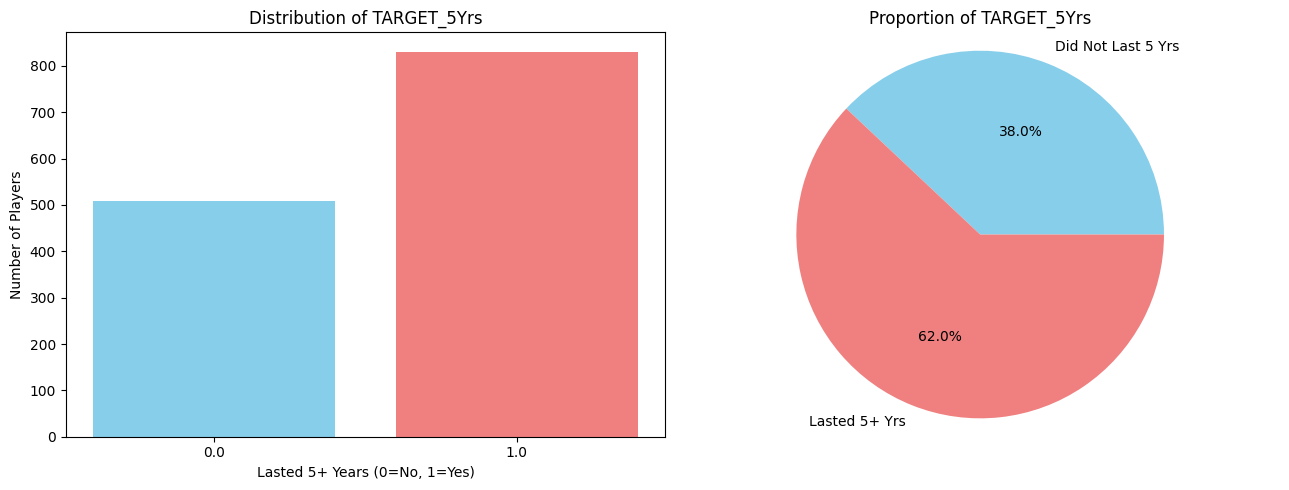

In [ ]:
import matplotlib.pyplot as plt

target_counts = df['TARGET_5Yrs'].value_counts().sort_index()
print(f'\nTarget variable distribution:')
print(f'  0 (did NOT last 5 yrs): {int(target_counts[0.0])}  ({target_counts[0.0]/len(df)*100:.1f}%)')
print(f'  1 (lasted 5+ yrs):      {int(target_counts[1.0])}  ({target_counts[1.0]/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar plot for target variable distribution
axes[0].bar(target_counts.index.astype(str), target_counts.values, color=['skyblue', 'lightcoral'])
axes[0].set_title('Distribution of TARGET_5Yrs')
axes[0].set_xlabel('Lasted 5+ Years (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Players')
axes[0].set_xticks([0, 1])

# Pie chart for target variable distribution
axes[1].pie(target_counts.values, labels=['Did Not Last 5 Yrs', 'Lasted 5+ Yrs'], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
axes[1].set_title('Proportion of TARGET_5Yrs')
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

### Handling Missing Values

The '3P%' column has 11 missing values. I will impute these missing values with the mean of the column.

In [ ]:
df['3P%'].fillna(df['3P%'].mean(), inplace=True)
print(f"Missing values after imputation:\n{df.isnull().sum()}")

Missing values after imputation:
Name           0
GP             0
MIN            0
PTS            0
FGM            0
FGA            0
FG%            0
3P Made        0
3PA            0
3P%            0
FTM            0
FTA            0
FT%            0
OREB           0
DREB           0
REB            0
AST            0
STL            0
BLK            0
TOV            0
TARGET_5Yrs    0
dtype: int64


/tmp/ipykernel_26979/2906920628.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['3P%'].fillna(df['3P%'].mean(), inplace=True)


### Handling Duplicate Values

There are 12 exact duplicate rows and 46 duplicate player names. I will remove both types of duplicates to ensure data quality. For duplicate player names, I'll keep the first entry, assuming it represents the most complete or relevant record.

In [ ]:
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after dropping: {df.duplicated().sum()}")

Duplicate rows after dropping: 0


In [ ]:
df.drop_duplicates(subset=['Name'], keep='first', inplace=True)
print(f'Duplicate player names after dropping: {df["Name"].duplicated().sum()}')
print(f'Dataset shape after handling duplicates: {df.shape}')

Duplicate player names after dropping: 0
Dataset shape after handling duplicates: (1294, 21)


In [ ]:
labels = ['Did NOT last\n5 years (0)', 'Lasted 5+\nyears (1)']
colors = ['#e74c3c', '#27ae60']
bars = axes[0].bar(labels, target_counts.values, color=colors,
                   edgecolor='black', linewidth=0.7, width=0.55)
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 12,
                 f'{int(val)}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Players')
axes[0].set_title('Target Variable — Count')

Text(0.5, 1.0, 'Target Variable — Count')

In [ ]:
axes[1].pie(target_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.7})
axes[1].set_title('Target Variable — Proportion')

plt.suptitle('Is the Dataset Balanced?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### Correlation Matrix Visualization

To understand the relationships between the different features, I will visualize the correlation matrix of the cleaned dataset using a heatmap. The 'Name' column will be excluded from this analysis as it is not a numerical feature.


Correlation of each feature with TARGET_5Yrs (sorted):
3P%       -0.011
3PA        0.015
3P Made    0.034
FT%        0.102
AST        0.177
BLK        0.216
STL        0.237
FG%        0.242
TOV        0.278
DREB       0.293
FGA        0.298
OREB       0.301
FTM        0.305
FTA        0.306
REB        0.308
PTS        0.323
FGM        0.325
MIN        0.327
GP         0.415


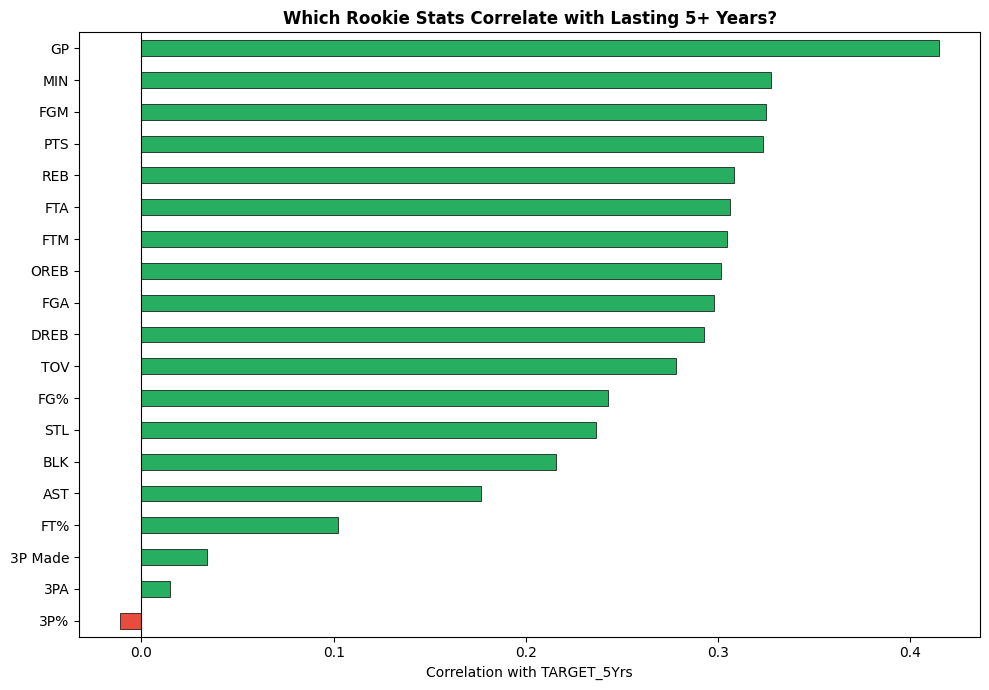

In [ ]:
target_corr = corr_matrix['TARGET_5Yrs'].drop('TARGET_5Yrs').sort_values(ascending=True)
print('\nCorrelation of each feature with TARGET_5Yrs (sorted):')
print(target_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#27ae60' if v > 0 else '#e74c3c' for v in target_corr.values]
target_corr.plot(kind='barh', color=bar_colors, edgecolor='black',
                 linewidth=0.5, ax=ax)
ax.set_title('Which Rookie Stats Correlate with Lasting 5+ Years?',
             fontweight='bold')
ax.set_xlabel('Correlation with TARGET_5Yrs')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Model Training and Evaluation

In [ ]:
# Define features (X) and target (y)
X = df.drop(['Name', 'TARGET_5Yrs'], axis=1)
y = df['TARGET_5Yrs']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation and scaling complete.")

Data preparation and scaling complete.


#### Logistic Regression

In [ ]:
# Initialize and train Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
Accuracy: 0.7413
Precision: 0.7513
Recall: 0.8765
ROC AUC: 0.8165

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.52      0.60        97
         1.0       0.75      0.88      0.81       162

    accuracy                           0.74       259
   macro avg       0.73      0.70      0.70       259
weighted avg       0.74      0.74      0.73       259



#### Random Forest Classifier

In [ ]:
# Initialize and train Random Forest Classifier model
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train, y_train) # Use unscaled data for tree-based models

# Make predictions
y_pred_rf = rand_forest.predict(X_test)
y_prob_rf = rand_forest.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 0.7220
Precision: 0.7419
Recall: 0.8519
ROC AUC: 0.7749

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.51      0.58        97
         1.0       0.74      0.85      0.79       162

    accuracy                           0.72       259
   macro avg       0.71      0.68      0.68       259
weighted avg       0.72      0.72      0.71       259



#### Decision Tree Classifier

In [ ]:
# Initialize and train Decision Tree Classifier model
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train) # Use unscaled data for tree-based models

# Make predictions
y_pred_dt = dec_tree.predict(X_test)
y_prob_dt = dec_tree.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier Performance:
Accuracy: 0.6255
Precision: 0.7181
Recall: 0.6605
ROC AUC: 0.6138

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.57      0.53        97
         1.0       0.72      0.66      0.69       162

    accuracy                           0.63       259
   macro avg       0.61      0.61      0.61       259
weighted avg       0.64      0.63      0.63       259



### Visualizing the Decision Tree

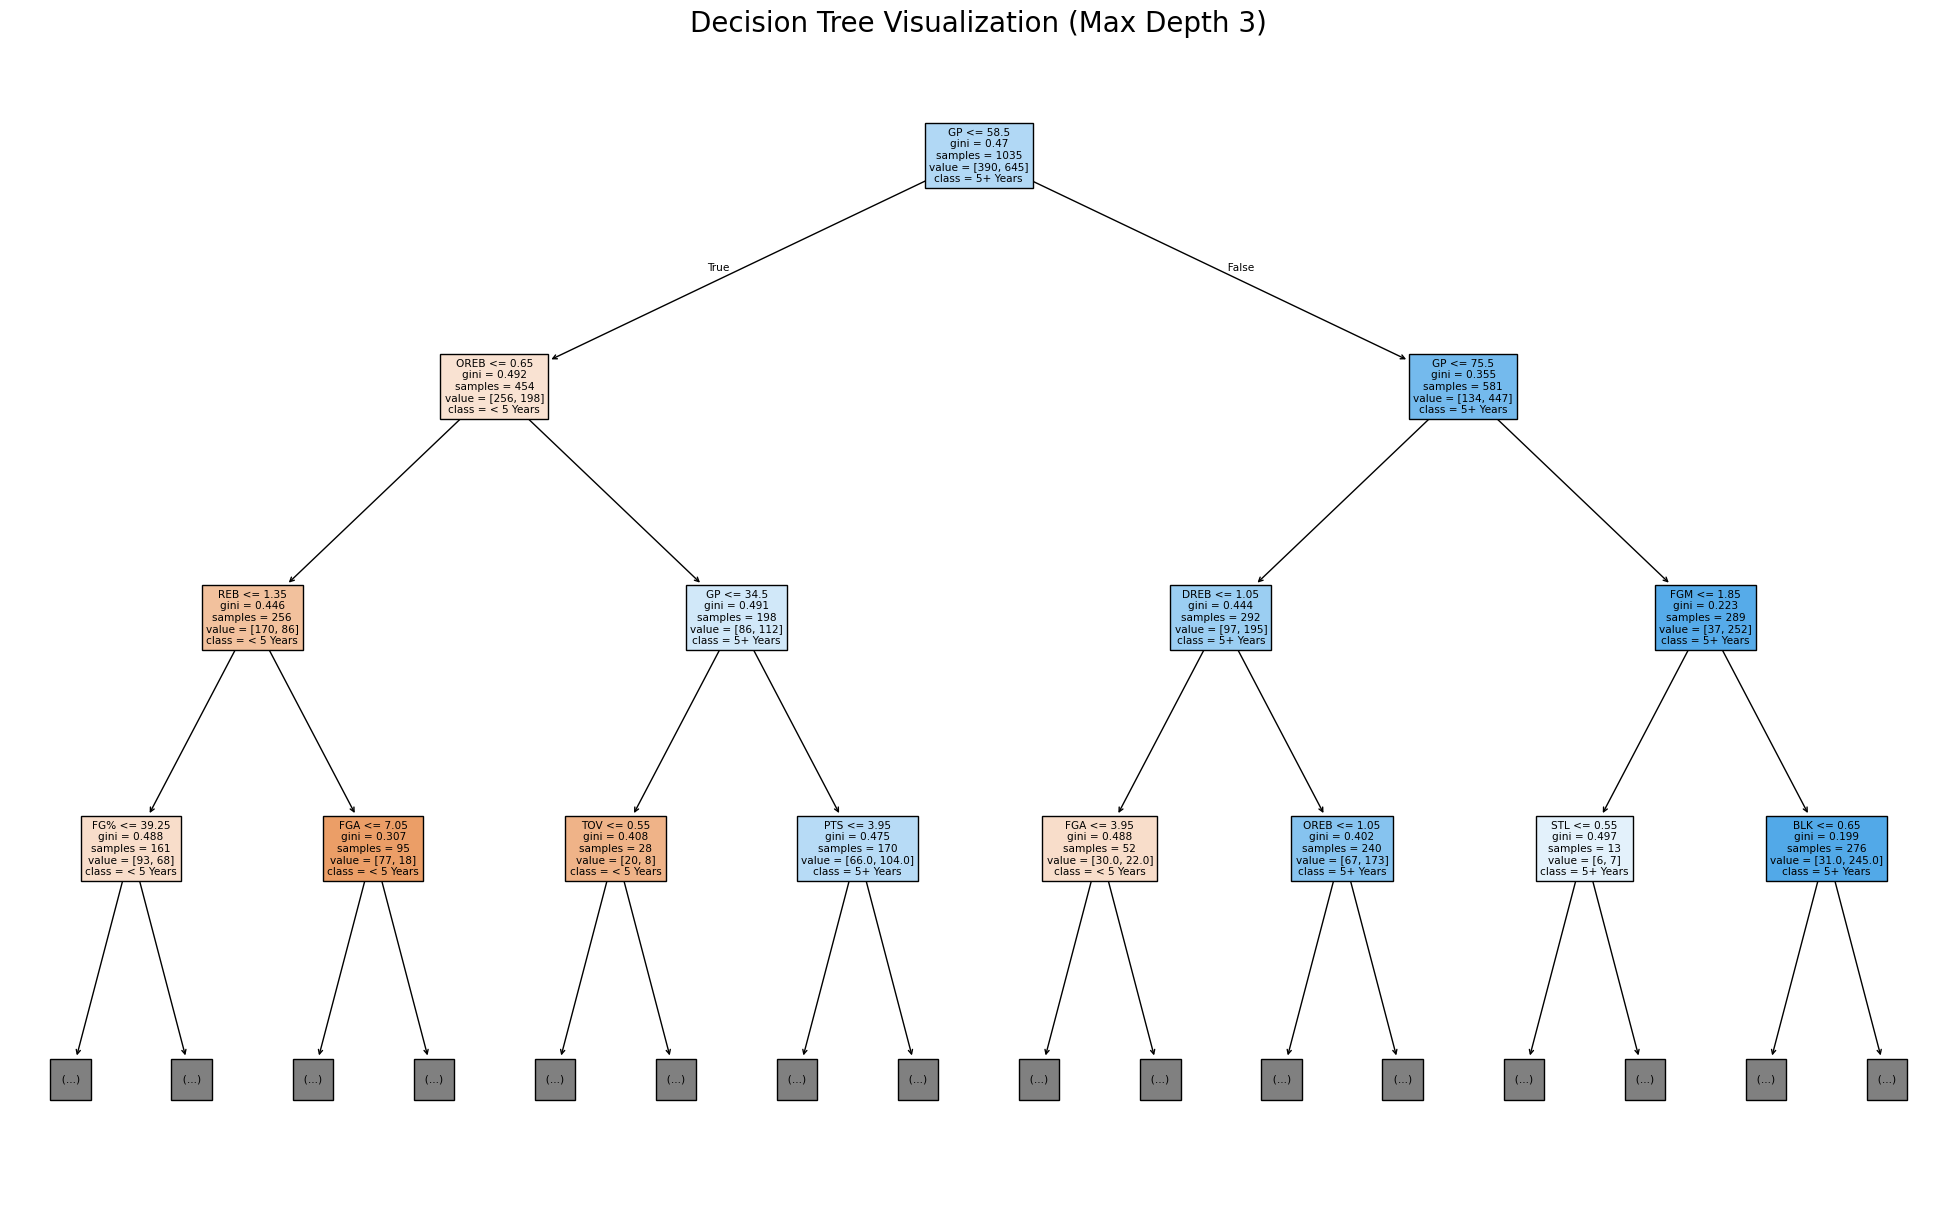

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 20)) # Adjust figsize for better visibility of a larger tree
plot_tree(dec_tree, filled=True, feature_names=X.columns, class_names=['< 5 Years', '5+ Years'])
plt.title('Decision Tree Visualization (Full Tree)', fontsize=20)
plt.show()

The visualization of the Decision Tree, limited to a `max_depth` of 3 for readability, shows the decision rules it has learned. To inspect for overfitting, we would typically look for a very deep tree with many nodes that make decisions based on very specific, perhaps noisy, training data. A very complex tree with high depth can indicate that the model has learned the training data too well, including its noise, and might not generalize well to unseen data. Since the current tree shows only the first few layers, if the full tree (without `max_depth` limit) were excessively deep and bushy, it would suggest overfitting.

### Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect metrics for each model
metrics = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'ROC AUC': roc_auc_score(y_test, y_prob_lr)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'ROC AUC': roc_auc_score(y_test, y_prob_rf)
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt),
        'Recall': recall_score(y_test, y_pred_dt),
        'ROC AUC': roc_auc_score(y_test, y_prob_dt)
    }
}

# Create a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics).T
print('Model Performance Comparison:')
display(metrics_df.round(4))


Model Performance Comparison:


,Accuracy,Precision,Recall,ROC AUC
Logistic Regression,0.7413,0.7513,0.8765,0.8165
Random Forest,0.7220,0.7419,0.8519,0.7749
Decision Tree,0.6255,0.7181,0.6605,0.6138


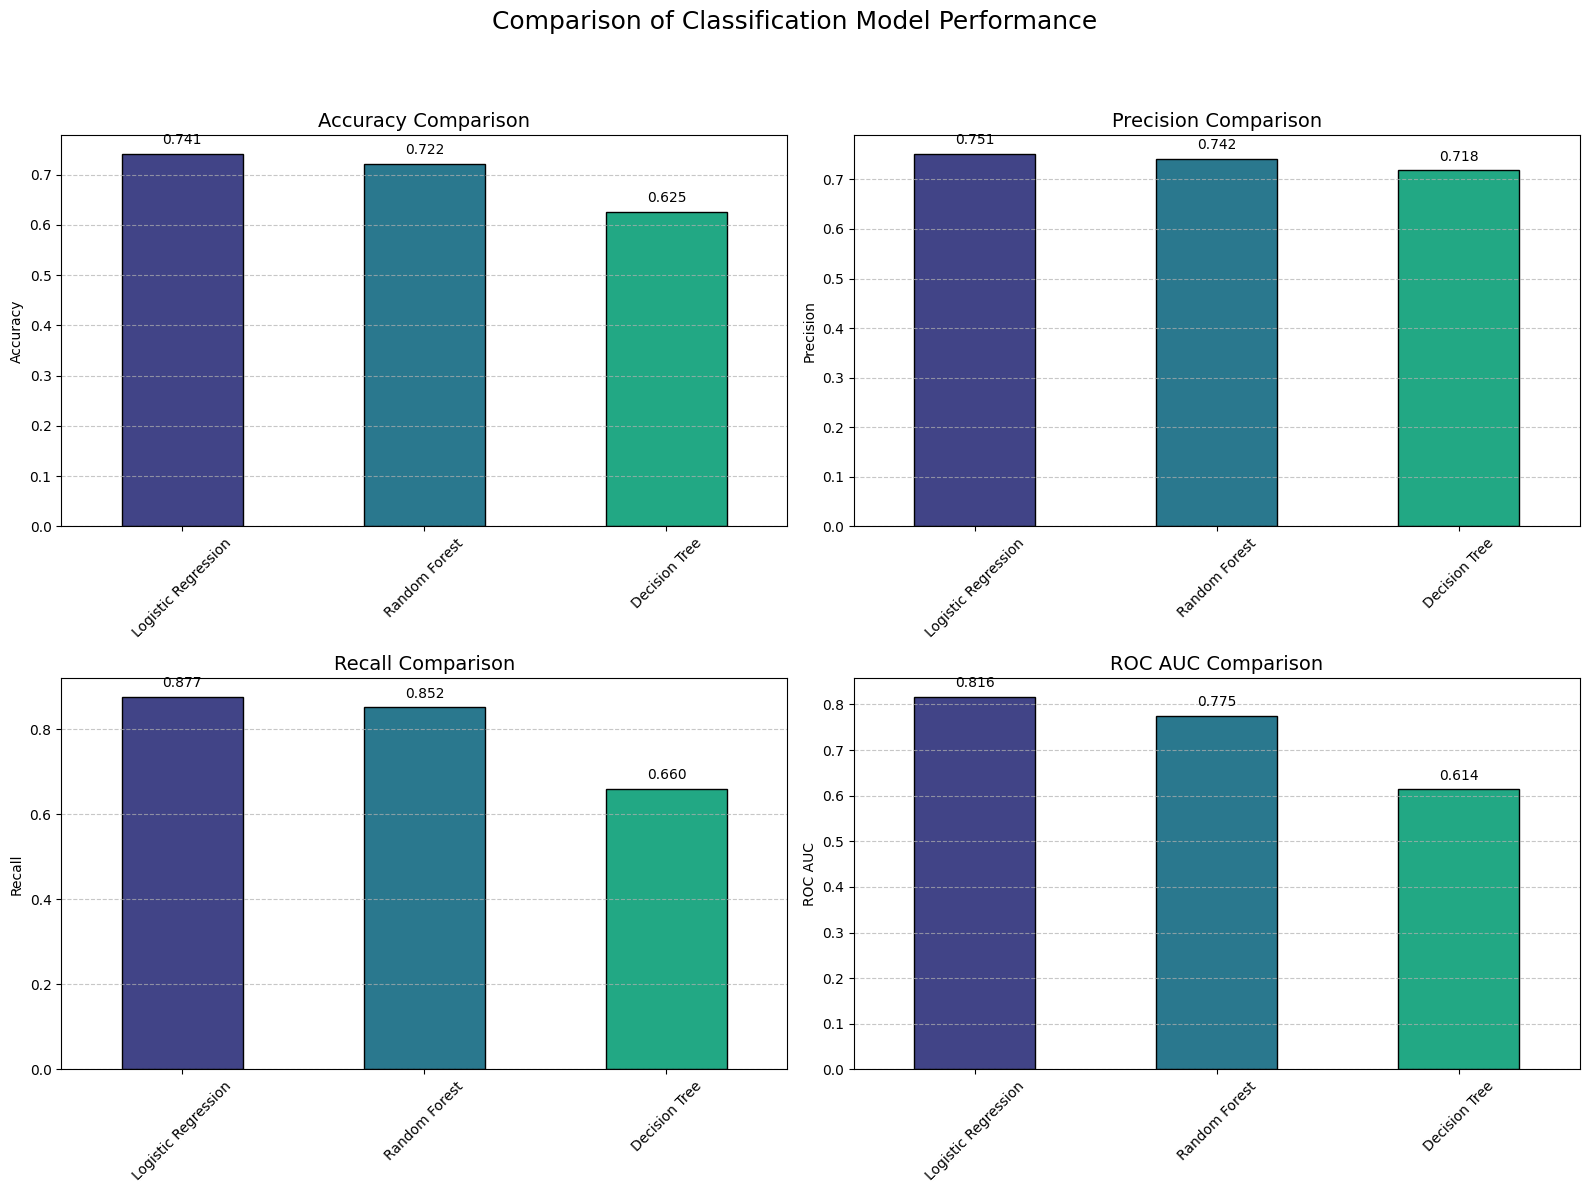

In [ ]:
# Visualize Model Performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metric_names = ['Accuracy', 'Precision', 'Recall', 'ROC AUC']
colors = sns.color_palette('viridis', n_colors=len(metrics_df.columns))

for i, metric in enumerate(metric_names):
    metrics_df[metric].plot(kind='bar', ax=axes[i], color=colors, edgecolor='black')
    axes[i].set_title(f'{metric} Comparison', fontsize=14)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.suptitle('Comparison of Classification Model Performance', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### Feature Importance (Random Forest)

Top 10 Feature Importances (Random Forest):


,Feature,Importance
0,GP,0.118593
5,FG%,0.078220
2,PTS,0.071893
11,FT%,0.063390
9,FTM,0.062694
1,MIN,0.058553
3,FGM,0.053257
4,FGA,0.052973
14,REB,0.050481
13,DREB,0.047608


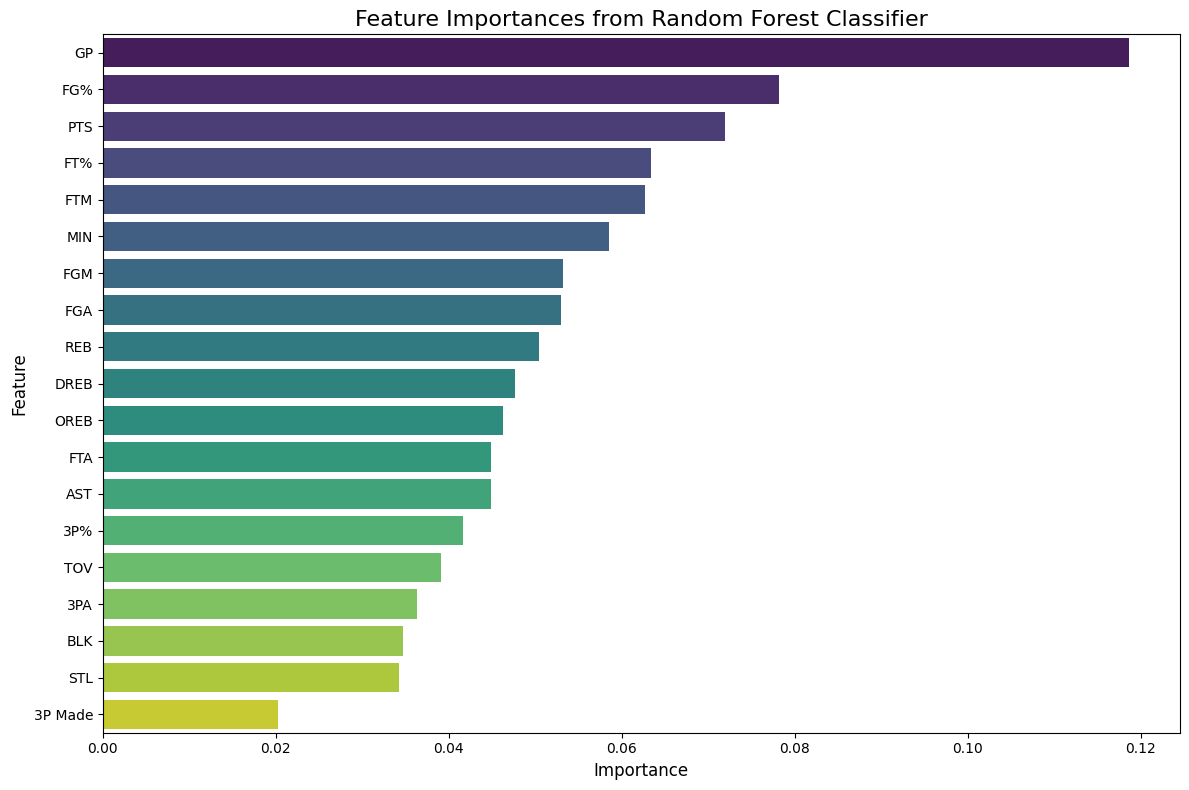

In [ ]:
feature_importances = rand_forest.feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})
features_df = features_df.sort_values(by='Importance', ascending=False)

print('Top 10 Feature Importances (Random Forest):')
display(features_df.head(10))
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances from Random Forest Classifier', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Decision Tree Accuracy:       {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest Accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")

Logistic Regression Accuracy: 0.7413
Decision Tree Accuracy:       0.6255
Random Forest Accuracy:       0.7220
